Import library

In [1]:
import os
import re
import cv2
import torch
import pandas as pd
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Check CUDA
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.empty_cache()
device

'cuda'

In [3]:
weights_path = os.path.join("..", "..", "..", "weights", "seed_count", "yolov8_seed_count_best.pt")
data_path = os.path.join("..", "..", "..", "sample_data", "annotated_panicles_lab")
weights_path, data_path

('..\\..\\..\\weights\\seed_count\\yolov8_seed_count_best.pt',
 '..\\..\\..\\sample_data\\annotated_panicles_lab')

Total seeds in front view: 677


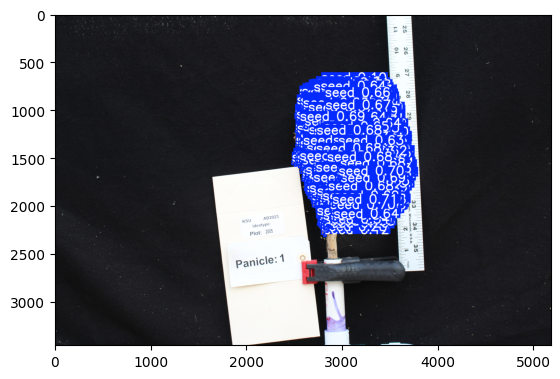

In [4]:
sample_image = os.path.join(data_path, '2005-SC964', '1. P1-WOF-Fr.jpg')
model = YOLO(weights_path)  # load a custom model
results = model(sample_image, max_det = 3000, conf = 0.1, verbose=False)
fig = plt.figure()
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
boxes_fr = results[0].boxes.xywh.cpu().numpy()
print("Total seeds in front view:", len(boxes_fr))
plt.imshow(detect_img)
plt.show()

Total seeds in back view: 713
Total seeds for the panicle (front+back): 1390


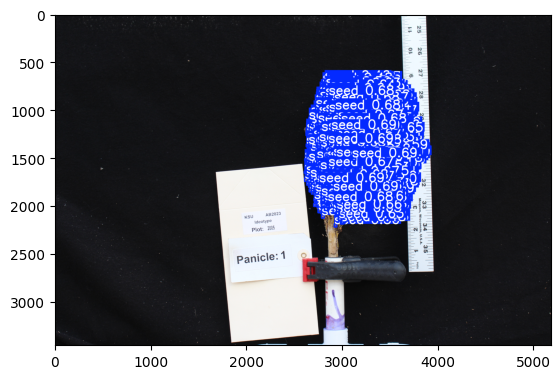

In [5]:
sample_image = os.path.join(data_path, '2005-SC964', '3. P1-WOF-Ba.jpg')
model = YOLO(weights_path)  # load a custom model
results = model(sample_image, max_det = 3000, conf = 0.1, verbose=False)
fig = plt.figure()
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
boxes_ba = results[0].boxes.xywh.cpu().numpy()
print("Total seeds in back view:", len(boxes_ba))
print("Total seeds for the panicle (front+back):", len(boxes_fr)+len(boxes_ba))
plt.imshow(detect_img)
plt.show()

## Dataframe created read the folders and images and put in the dataframe

In [6]:
df = pd.DataFrame(columns=['id', 'image_name', 'rep', 'seed_counts'])
data = []
for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    r = 1
    images = [f for f in files if (f.endswith('JPG'.lower()))] # filter images
    if not images:
        continue # if there are no image in the folder, then continue loop
    for file in files:
        if (file.endswith('JPG'.lower())):
            if 'P1' in file:
                r = 1
            elif 'P2' in file:
                r = 2
            elif 'P3' in file:
                r = 3
            elif 'P4' in file:
                r = 4
            data.append([folder_name, file, r])

df[['id', 'image_name', 'rep']] = data
df

,id,image_name,rep,seed_counts
0,2005-SC964,1. P1-WOF-Fr.jpg,1,NaN
1,2005-SC964,11. P3-WOF-Ba.jpg,3,NaN
2,2005-SC964,13. P4-WOF-Fr.jpg,4,NaN
3,2005-SC964,15. P4-WOF-Ba.jpg,4,NaN
4,2005-SC964,3. P1-WOF-Ba.jpg,1,NaN
5,2005-SC964,5. P2-WOF-Fr.jpg,2,NaN
6,2005-SC964,7. P2-WOF-Ba.jpg,2,NaN
7,2005-SC964,9. P3-WOF-Fr.jpg,3,NaN
8,2009-RTx430BL,1. P1-WOF-Fr.jpg,1,NaN
9,2009-RTx430BL,11. P3-WOF-Ba.jpg,3,NaN


In [7]:
# Initialize an empty list to store results
output_dir = r'predicted_outputs'
conf_val = 0.1

# Make a pandas dataframe
for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    if folder_name == os.path.basename(data_path):
        continue
    # Create a corresponding output folder for this subfolder
    folder_output_dir = os.path.join(output_dir, folder_name)
    os.makedirs(folder_output_dir, exist_ok=True)
    image_folder_path = os.path.join(data_path, folder_name)
    images = [f for f in files if (f.endswith('JPG'.lower()))] # filter images
    if not images:
        continue # if there are no image in the folder, then continue loop
    annotations = [f for f in files if f.endswith('.json'.lower())] # filter annotations
    images.sort()
    annotations.sort()
    for idx, img in enumerate(images):
        img_path = os.path.join(image_folder_path, img)

        # Perform inference
        result = model(img_path, max_det = 3000, conf = conf_val, show_labels=False,show_conf=False)
        
        # Extract the bounding boxes
        boxes = result[0].boxes.xywh.cpu().numpy()  # Convert tensor to NumPy array for compatibility
        num_boxes = len(boxes)
        df.loc[(df['id']==folder_name) & (df['image_name']==img), 'seed_counts'] = num_boxes
        
        # Draw the bounding boxes on the image
        detect_img = result[0].plot()
        
        # Save the image with bounding boxes
        output_image_path = os.path.join(folder_output_dir, img)
        cv2.imwrite(output_image_path, detect_img)
df

,id,image_name,rep,seed_counts
0,2005-SC964,1. P1-WOF-Fr.jpg,1,677
1,2005-SC964,11. P3-WOF-Ba.jpg,3,635
2,2005-SC964,13. P4-WOF-Fr.jpg,4,811
3,2005-SC964,15. P4-WOF-Ba.jpg,4,715
4,2005-SC964,3. P1-WOF-Ba.jpg,1,713
5,2005-SC964,5. P2-WOF-Fr.jpg,2,471
6,2005-SC964,7. P2-WOF-Ba.jpg,2,481
7,2005-SC964,9. P3-WOF-Fr.jpg,3,602
8,2009-RTx430BL,1. P1-WOF-Fr.jpg,1,388
9,2009-RTx430BL,11. P3-WOF-Ba.jpg,3,304


In [8]:
# Step 2: Extract the image type (P1, P2, P3, or P4) from the 'image_name' column
def extract_image_type(image_name):
    # Use regular expressions to find P1, P2, P3, or P4 in the image_name
    match = re.search(r'P[1-4]', image_name)
    return match.group(0) if match else None

df['image_type'] = df['image_name'].apply(extract_image_type)

# Step 3: Group by 'id' and 'image_type' and sum the 'seed_counts' for each group
result_df = df.groupby(['id', 'image_type'])['seed_counts'].sum().reset_index()

# Step 4: Add a new 'image_name' column with predefined values based on the image type
# Dictionary to map each image_type to its corresponding image name
image_rep_map = {
    'P1': '1',
    'P2': '2',
    'P3': '3',
    'P4': '4'
}

# Map the image name to the 'image_type' column
result_df['rep'] = result_df['image_type'].map(image_rep_map)
result_df

,id,image_type,seed_counts,rep
0,2005-SC964,P1,1390,1
1,2005-SC964,P2,952,2
2,2005-SC964,P3,1237,3
3,2005-SC964,P4,1526,4
4,2009-RTx430BL,P1,793,1
5,2009-RTx430BL,P2,760,2
6,2009-RTx430BL,P3,631,3
7,2009-RTx430BL,P4,784,4
8,2013-Tx7000,P1,1305,1
9,2013-Tx7000,P2,1889,2


In [9]:
result_df.to_csv('predicted_panicle_seed_counts.csv', index=False)